In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import os
from tqdm import tqdm
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
import dill

In [3]:
df = pd.read_csv('final_w_features.csv')
df['date'] = pd.to_datetime(df['date'])
targets = {1: 'gage_height_t1', 3: 'gage_height_t3', 7: 'gage_height_t7'}
feature_cols = [c for c in df.columns
                if c not in list(targets.values()) + ['date', 'gage_height']]

## Comparing LightGBM and XGBoost using walk-forward CV with 5 splits and 3 time horizons (1, 3, and 7 days)
This also trains 3 models using quantile regression: 2.5, 50, and 97.5

In [3]:
# LIGHTGBM VERSION
# Number of horizons to forecast
horizons = [1, 3, 7]
# Quantiles to use
quantiles = [0.025, 0.50, 0.975]
# Number of walk-forward splits
n_splits  = 5

all_results = {}

def make_model(alpha):
    return LGBMRegressor(
        objective='quantile',
        alpha=alpha,
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=59,
        verbose=-1
    )

for horizon in horizons:
    target_col = targets[horizon]
    X = df[feature_cols]
    y = df[target_col]

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        preds = {}

        # Iterate through quantiles
        for q in quantiles:
            # Make model
            model = make_model(alpha=q)
            # Fit
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(False)]
            )
            # Predict
            preds[q] = model.predict(X_val)

        # Metrics on median model
        mae = mean_absolute_error(y_val, preds[0.50])
        rmse = root_mean_squared_error(y_val, preds[0.50])

        # Interval coverage - % of true values falling within 10th-90th percentile
        coverage = np.mean((y_val.values >= preds[0.025]) &
                          (y_val.values <= preds[0.975]))

        # Interval width - average widtch of prediction interval
        interval_width = np.mean(preds[0.975] - preds[0.025])

        # Save metrics
        fold_metrics.append({
            'fold': fold + 1,
            'train_size': len(train_idx),
            'val_size': len(val_idx),
            'mae': mae,
            'rmse': rmse,
            'coverage': coverage,
            'interval_width': interval_width
        })

        print(f"Horizon {horizon}d | Fold {fold+1} |"
             f"MAE: {mae:.3f} ft | RMSE: {rmse:.3f} ft | "
             f"Coverage: {coverage:.1%} | "
             f"Interval Width: {interval_width:.3f} ft")
    
    results_df = pd.DataFrame(fold_metrics)
    all_results[horizon] = results_df
    print(f"\nHorizon {horizon}d summary -"
         f" MAE: {results_df['mae'].mean():.3f} ± {results_df['mae'].std():.3f} ft | "
         f"RMSE: {results_df['rmse'].mean():.3f} ± {results_df['rmse'].std():.3f} ft | "
         f"Coverage: {results_df['coverage'].mean():.1%} | "
         f"Interval Width: {results_df['interval_width'].mean():.3f} ft\n")

print('CV complete.')

Horizon 1d | Fold 1 |MAE: 0.227 ft | RMSE: 0.939 ft | Coverage: 93.4% | Interval Width: 1.203 ft
Horizon 1d | Fold 2 |MAE: 0.222 ft | RMSE: 0.794 ft | Coverage: 87.5% | Interval Width: 0.935 ft
Horizon 1d | Fold 3 |MAE: 0.284 ft | RMSE: 0.987 ft | Coverage: 88.3% | Interval Width: 0.988 ft
Horizon 1d | Fold 4 |MAE: 0.182 ft | RMSE: 0.572 ft | Coverage: 81.2% | Interval Width: 0.895 ft
Horizon 1d | Fold 5 |MAE: 0.193 ft | RMSE: 0.652 ft | Coverage: 79.5% | Interval Width: 0.904 ft

Horizon 1d summary - MAE: 0.222 ± 0.040 ft | RMSE: 0.789 ± 0.179 ft | Coverage: 86.0% | Interval Width: 0.985 ft

Horizon 3d | Fold 1 |MAE: 0.404 ft | RMSE: 1.271 ft | Coverage: 92.4% | Interval Width: 2.732 ft
Horizon 3d | Fold 2 |MAE: 0.427 ft | RMSE: 1.212 ft | Coverage: 92.0% | Interval Width: 2.956 ft
Horizon 3d | Fold 3 |MAE: 0.556 ft | RMSE: 1.613 ft | Coverage: 86.6% | Interval Width: 2.550 ft
Horizon 3d | Fold 4 |MAE: 0.386 ft | RMSE: 1.154 ft | Coverage: 86.3% | Interval Width: 3.123 ft
Horizon 3d |

In [35]:
# XGBOOST VERSION
# Number of horizons to forecast
horizons = [1, 3, 7]
# Quantiles to use
quantiles = [0.025, 0.50, 0.975]
# Number of walk-forward splits
n_splits  = 5

all_results = {}

def make_model(alpha):
    return XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=alpha,
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=59
    )

for horizon in horizons:
    target_col = targets[horizon]
    X = df[feature_cols]
    y = df[target_col]

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        preds = {}

        # Iterate through quantiles
        for q in quantiles:
            # Make model
            model = make_model(alpha=q)
            # Fit
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )
            # Predict
            preds[q] = model.predict(X_val)

        # Metrics on median model
        mae = mean_absolute_error(y_val, preds[0.50])
        rmse = root_mean_squared_error(y_val, preds[0.50])

        # Interval coverage - % of true values falling within 10th-90th percentile
        coverage = np.mean((y_val.values >= preds[0.025]) &
                          (y_val.values <= preds[0.975]))

        # Interval width - average widtch of prediction interval
        interval_width = np.mean(preds[0.975] - preds[0.025])

        # Save metrics
        fold_metrics.append({
            'fold': fold + 1,
            'train_size': len(train_idx),
            'val_size': len(val_idx),
            'mae': mae,
            'rmse': rmse,
            'coverage': coverage,
            'interval_width': interval_width
        })

        print(f"Horizon {horizon}d | Fold {fold+1} |"
             f"MAE: {mae:.3f} ft | RMSE: {rmse:.3f} ft | "
             f"Coverage: {coverage:.1%} | "
             f"Interval Width: {interval_width:.3f} ft")
    
    results_df = pd.DataFrame(fold_metrics)
    all_results[horizon] = results_df
    print(f"\nHorizon {horizon}d summary -"
         f" MAE: {results_df['mae'].mean():.3f} ± {results_df['mae'].std():.3f} ft | "
         f"RMSE: {results_df['rmse'].mean():.3f} ± {results_df['rmse'].std():.3f} ft | "
         f"Coverage: {results_df['coverage'].mean():.1%} | "
         f"Interval Width: {results_df['interval_width'].mean():.3f} ft\n")

print('CV complete.')

Horizon 1d | Fold 1 |MAE: 0.215 ft | RMSE: 0.866 ft | Coverage: 91.4% | Interval Width: 0.992 ft
Horizon 1d | Fold 2 |MAE: 0.216 ft | RMSE: 0.756 ft | Coverage: 89.1% | Interval Width: 1.012 ft
Horizon 1d | Fold 3 |MAE: 0.283 ft | RMSE: 0.983 ft | Coverage: 85.8% | Interval Width: 1.128 ft
Horizon 1d | Fold 4 |MAE: 0.180 ft | RMSE: 0.577 ft | Coverage: 80.2% | Interval Width: 1.031 ft
Horizon 1d | Fold 5 |MAE: 0.193 ft | RMSE: 0.659 ft | Coverage: 67.3% | Interval Width: 0.898 ft

Horizon 1d summary - MAE: 0.217 ± 0.040 ft | RMSE: 0.768 ± 0.161 ft | Coverage: 82.8% | Interval Width: 1.012 ft

Horizon 3d | Fold 1 |MAE: 0.406 ft | RMSE: 1.263 ft | Coverage: 89.3% | Interval Width: 1.864 ft
Horizon 3d | Fold 2 |MAE: 0.428 ft | RMSE: 1.214 ft | Coverage: 89.8% | Interval Width: 2.372 ft
Horizon 3d | Fold 3 |MAE: 0.557 ft | RMSE: 1.611 ft | Coverage: 83.6% | Interval Width: 2.156 ft
Horizon 3d | Fold 4 |MAE: 0.387 ft | RMSE: 1.151 ft | Coverage: 83.9% | Interval Width: 2.991 ft
Horizon 3d |

## Final model fitting

In [14]:
# Setup
HORIZONS = [1, 3, 7]
QUANTILES = [0.025, 0.50, 0.975]
HOLDOUT_DAYS = 365

# Train/test split
df_sorted = df.sort_values('date').reset_index(drop=True)
train_df = df_sorted.iloc[:-HOLDOUT_DAYS]
test_df = df_sorted.iloc[-HOLDOUT_DAYS:]
feature_cols = [c for c in df.columns
                if c not in list(targets.values()) + ['date', 'gage_height']]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
print(f'Training set: {train_df['date'].min().date()} to {train_df['date'].max().date()} ({len(train_df)} days)')
print(f'Testing set: {test_df['date'].min().date()} to {test_df['date'].max().date()} ({len(test_df)} days)')

Training set: 2007-11-15 to 2023-12-17 (5866 days)
Testing set: 2023-12-18 to 2024-12-16 (365 days)


In [5]:
def make_model(alpha):
    return LGBMRegressor(
        objective='quantile',
        alpha=alpha,
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=59,
        verbose=-1
    )

final_models = {}
test_predictions = {}

for horizon in HORIZONS:
    target_col = targets[horizon]
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    horizon_models = {}
    horizon_preds = {}

    for q in QUANTILES:
        model = make_model(alpha=q)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(False)
            ]
        )

        horizon_models[q] = model
        horizon_preds[q] = model.predict(X_test)

    final_models[horizon] = horizon_models
    test_predictions[horizon] = horizon_preds

    # Evaluate on holdout
    mae = mean_absolute_error(y_test, horizon_preds[0.50])
    rmse = root_mean_squared_error(y_test, horizon_preds[0.50])
    coverage = np.mean(
        (y_test.values >= horizon_preds[0.025]) &
        (y_test.values <= horizon_preds[0.975])
    )
    width = np.mean(horizon_preds[0.975] - horizon_preds[0.025])

    print(f'\nHorizon {horizon}d | Holdout Test Set')
    print(f'  MAE:                {mae:.3f} ft')
    print(f'  RMSE:               {rmse:.3f} ft')
    print(f'  Coverage:           {coverage:.1%}')
    print(f'  Interval width:     {width:.3f} ft')

# Save models
with open('final_models.dill', 'wb') as f:
    dill.dump(final_models, f)


Horizon 1d | Holdout Test Set
  MAE:                0.277 ft
  RMSE:               1.089 ft
  Coverage:           83.8%
  Interval width:     0.962 ft

Horizon 3d | Holdout Test Set
  MAE:                0.521 ft
  RMSE:               1.773 ft
  Coverage:           81.9%
  Interval width:     3.026 ft

Horizon 7d | Holdout Test Set
  MAE:                0.680 ft
  RMSE:               1.939 ft
  Coverage:           83.8%
  Interval width:     4.031 ft


## Plotting

### Predicted vs actual

In [6]:
percentile_thresholds = {
    'Action':   np.round(np.percentile(df['gage_height'], 85), 2),
    'Flood':    np.round(np.percentile(df['gage_height'], 95), 2),
    'Moderate': np.round(np.percentile(df['gage_height'], 98), 2),
    'Major':  np.round(np.percentile(df['gage_height'], 99.5), 2),
}

nws_thresholds = {
    'Action': 15.00,
    'Flood': 17.00,
    'Moderate': 25.00,
    'Major': 32.00,
}

threshold_colors = {
    'Action': 'yellow',
    'Flood': 'orange',
    'Moderate': 'red',
    'Major': 'darkred'
}

horizon_labels = {1: '1-Day Ahead', 3: '3-Day Ahead', 7: '7-Day Ahead'}

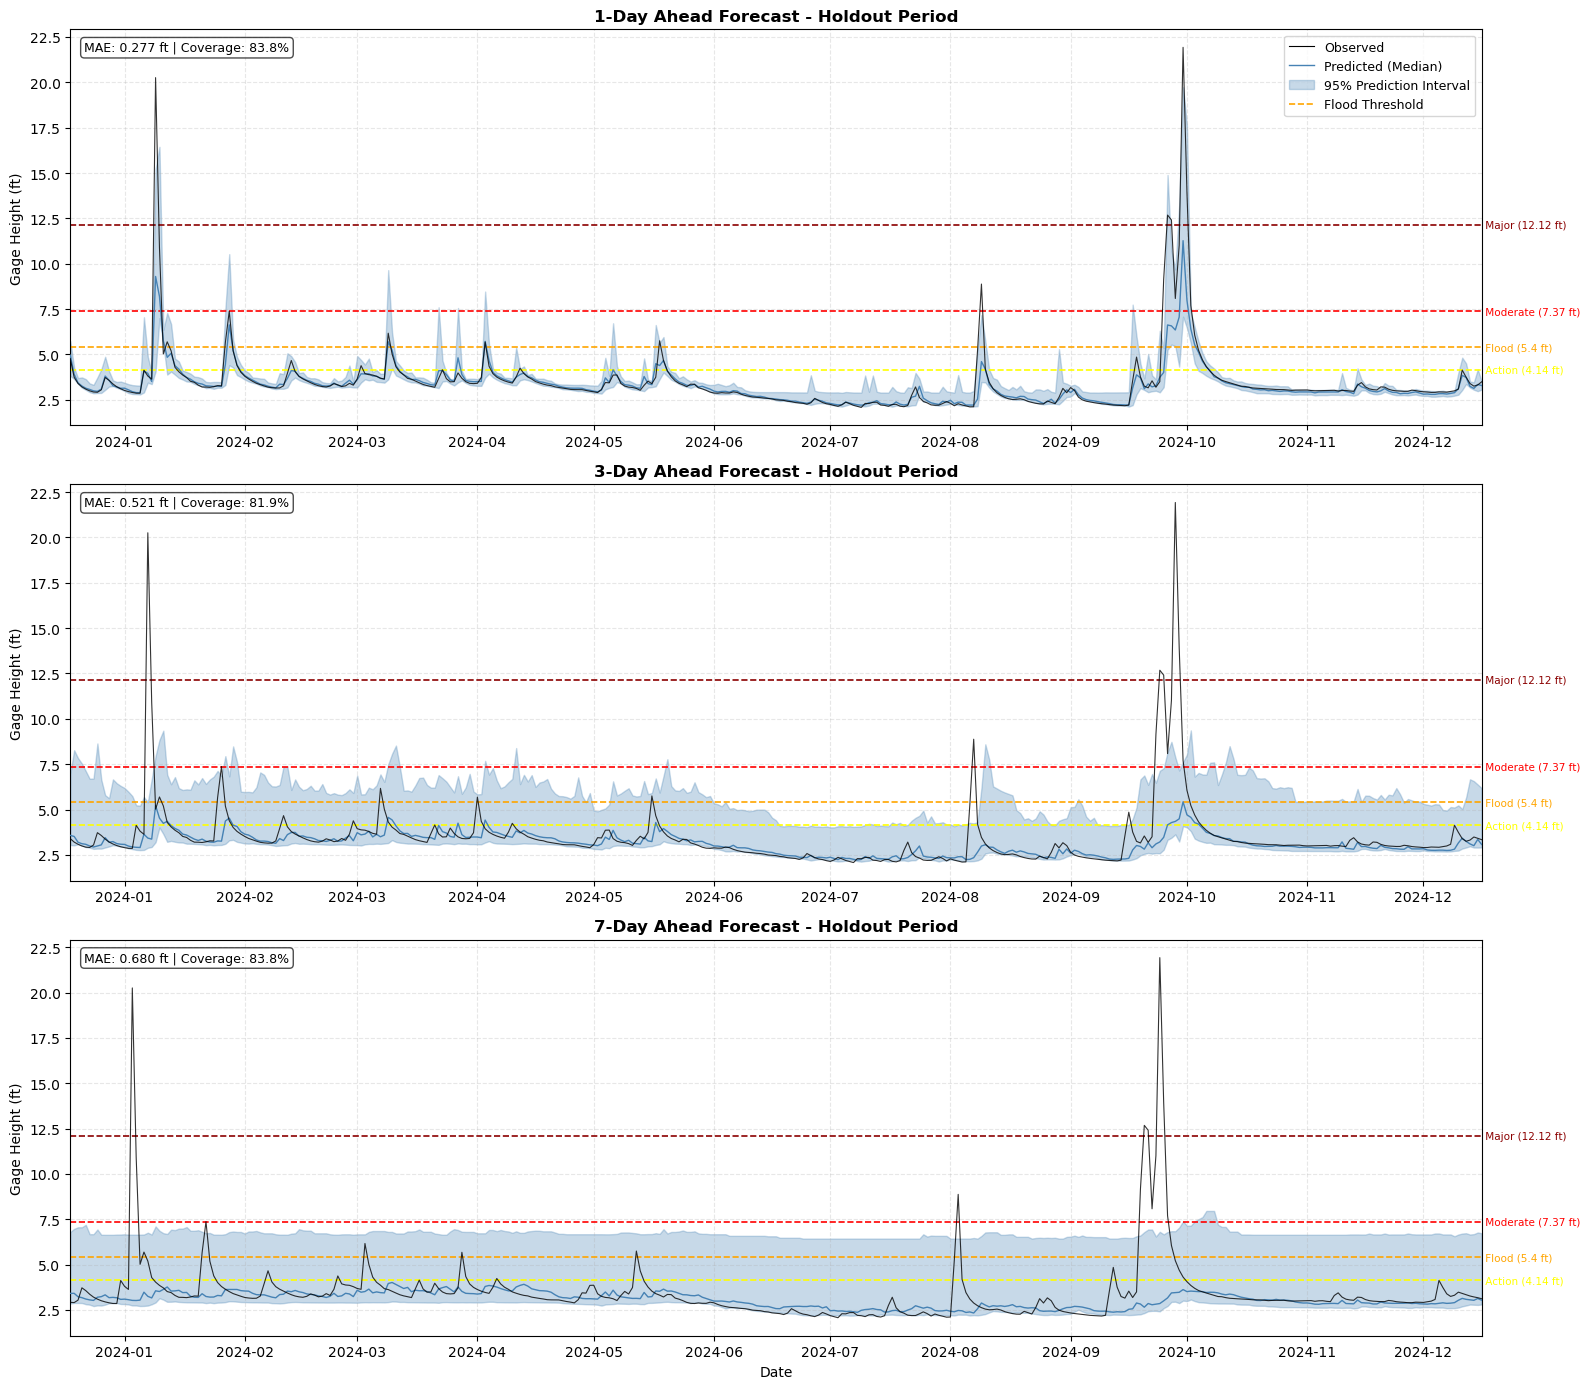

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

for ax, horizon in zip(axes, HORIZONS):
    target_col = targets[horizon]
    y_test = test_df[target_col].values
    dates = pd.to_datetime(test_df['date'])

    pred_lower = test_predictions[horizon][0.025]
    pred_median = test_predictions[horizon][0.50]
    pred_upper = test_predictions[horizon][0.975]

    # Make confidence interval band
    ax.fill_between(
        dates, pred_lower, pred_upper,
        alpha=0.3, color='steelblue', label='95% Prediction Interval'
    )

    # Plot predictions and observed
    ax.plot(dates, pred_median, color='steelblue', linewidth=1.0,
            label='Predicted (Median)', zorder=3)
    ax.plot(dates, y_test, color='black', linewidth=0.8,
            alpha=0.8, label='Observed', zorder=4)

    # Plot threshold lines
    for name, value in percentile_thresholds.items():
        ax.axhline(
            value, color=threshold_colors[name],
            linestyle='--', linewidth=1.2, zorder=2
        )
        ax.text(
            dates.iloc[-1], value, f' {name} ({value} ft)',
            va='center', fontsize=7.5, color=threshold_colors[name]
        )

    # Formatting
    ax.set_title(f'{horizon_labels[horizon]} Forecast - Holdout Period',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Gage Height (ft)', fontsize=10)
    ax.set_xlim(dates.iloc[0], dates.iloc[-1])
    ax.grid(True, alpha=0.3, linestyle='--')

    # Metrics
    mae = mean_absolute_error(y_test, pred_median)
    coverage = np.mean(
        (y_test >= pred_lower) &
        (y_test <= pred_upper)
    )
    ax.annotate(
        f'MAE: {mae:.3f} ft | Coverage: {coverage:.1%}',
        xy=(0.01, 0.97), xycoords='axes fraction',
        fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

    if horizon == 1:
        observed_line = mlines.Line2D([], [], color='black', linewidth=0.8, label='Observed')
        predicted_line = mlines.Line2D([], [], color='steelblue', linewidth=1.0, label='Predicted (Median)')
        interval_patch = mpatches.Patch(color='steelblue', alpha=0.3, label='95% Prediction Interval')
        threshold_patch = mlines.Line2D([], [], color='orange', linestyle='--', linewidth=1.2, label='Flood Threshold')
        ax.legend(
            handles=[observed_line, predicted_line, interval_patch, threshold_patch],
            loc='upper right', fontsize=9, framealpha=0.8
        )
axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion matrix of predictions for each threshold

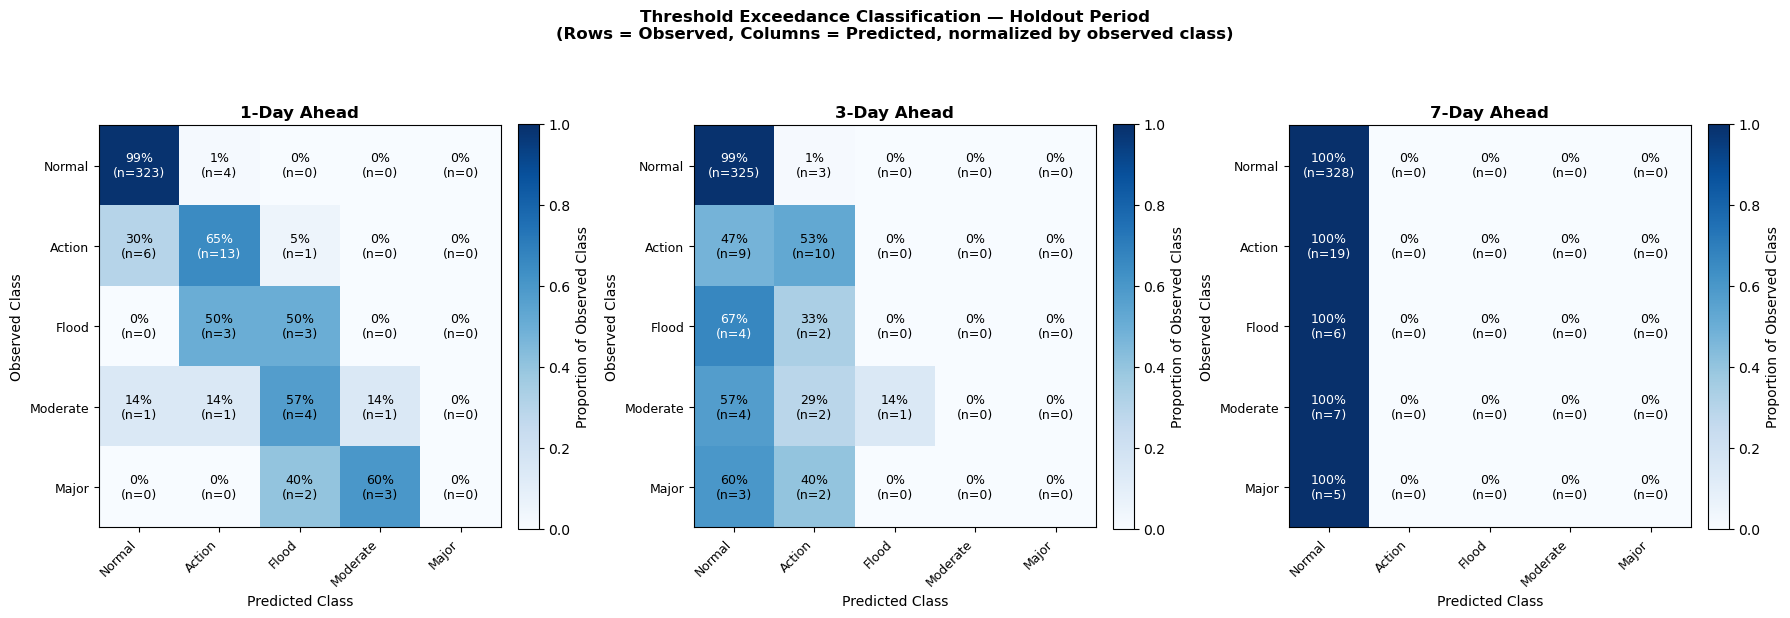

In [15]:
def classify_threshold(values, thresholds):
    labels = np.zeros(len(values), dtype=int)
    for i, (name, value) in enumerate(thresholds.items(), start=1):
        labels[values >= value] = i
    return labels

class_names = ['Normal', 'Action', 'Flood', 'Moderate', 'Major']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, horizon in zip(axes, HORIZONS):
    targe_col = targets[horizon]
    y_test = test_df[targe_col].values
    pred_median = test_predictions[horizon][0.50]

    # Classify observed and predicted
    y_true_class = classify_threshold(y_test, percentile_thresholds)
    y_pred_class = classify_threshold(pred_median, percentile_thresholds)

    # Identify which classes actually appear in holdout
    present_classes = sorted(set(y_true_class) | set(y_pred_class))
    present_names = [class_names[i] for i in present_classes]

    # Compute confusion matrix
    cm = confusion_matrix(y_true_class, y_pred_class, labels=present_classes)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Plot
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

    # Annotate each cell with normalized % and raw count
    for row in range(len(present_classes)):
        for col in range(len(present_classes)):
            raw   = cm[row, col]
            norm  = cm_normalized[row, col]
            color = 'white' if norm > 0.6 else 'black'
            ax.text(col, row, f'{norm:.0%}\n(n={raw})',
                    ha='center', va='center',
                    fontsize=9, color=color)

    # Axis formatting
    ax.set_xticks(range(len(present_classes)))
    ax.set_yticks(range(len(present_classes)))
    ax.set_xticklabels(present_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(present_names, fontsize=9)
    ax.set_xlabel('Predicted Class', fontsize=10)
    ax.set_ylabel('Observed Class', fontsize=10)
    ax.set_title(f'{horizon_labels[horizon]}', fontsize=12, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='Proportion of Observed Class')

fig.suptitle(
    'Threshold Exceedance Classification — Holdout Period\n'
    '(Rows = Observed, Columns = Predicted, normalized by observed class)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('threshold_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Forecast card comparing all three horizons together

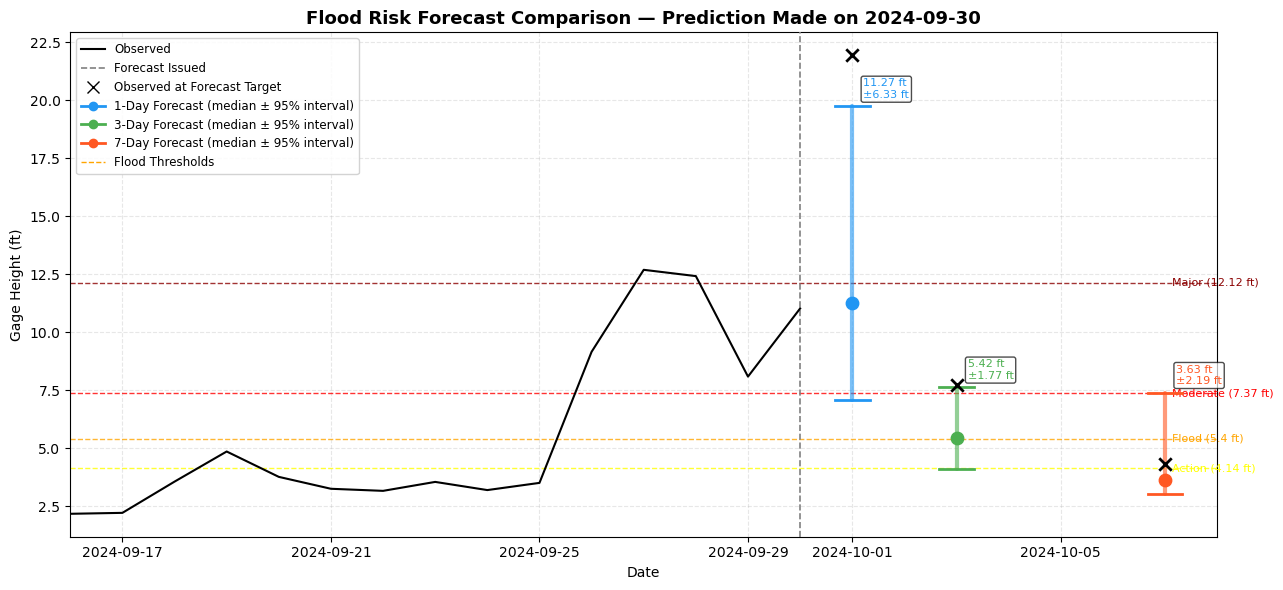

In [31]:
FORECAST_DATE = test_df['date'].iloc[287]

HORIZON_COLORS = {
    1: '#2196F3',   # Blue
    3: '#4CAF50',   # Green
    7: '#FF5722',   # Deep orange
}

N_CONTEXT_DAYS = 14   # Days of observed history to show before forecast date

# ── Locate forecast date in test set ──────────────────────────────────────────

test_df_ = test_df.copy()
test_df_['date'] = pd.to_datetime(test_df_['date'])
forecast_date    = pd.to_datetime(FORECAST_DATE)

forecast_idx = test_df_[test_df_['date'] == forecast_date].index
if len(forecast_idx) == 0:
    raise ValueError(f"Forecast date {forecast_date.date()} not found in test_df.")
forecast_idx = forecast_idx[0]

# ── Build context window (observed history before forecast date) ───────────────

context = test_df_.loc[
    test_df_['date'] <= forecast_date
].tail(N_CONTEXT_DAYS + 1)

context_dates  = context['date']
context_values = context['gage_height']

# ── Build forecast points (one per horizon) ───────────────────────────────────

forecast_points = {}
for horizon in HORIZONS:
    # Find the row in test_df where the forecast for this horizon was made
    # from forecast_date — that row's prediction corresponds to the value
    # at forecast_date + horizon days
    row_idx = test_df_[test_df_['date'] == forecast_date].index
    if len(row_idx) == 0:
        continue
    row_pos = test_df_.index.get_loc(row_idx[0])

    target_date = forecast_date + pd.Timedelta(days=horizon)
    forecast_points[horizon] = {
        'date':   target_date,
        'lower':  test_predictions[horizon][0.025][row_pos],
        'median': test_predictions[horizon][0.50][row_pos],
        'upper':  test_predictions[horizon][0.975][row_pos],
    }

    # Also get observed value at target date if available
    obs_row = test_df_[test_df_['date'] == target_date]
    forecast_points[horizon]['observed'] = (
        obs_row['gage_height'].values[0] if len(obs_row) > 0 else None
    )

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))

# Observed context window
ax.plot(
    context_dates, context_values,
    color='black', linewidth=1.5, zorder=5, label='Observed'
)
ax.axvline(
    forecast_date, color='gray', linestyle='--',
    linewidth=1.2, zorder=4, label='Forecast Issued'
)

# Forecast points per horizon
for horizon, fp in forecast_points.items():
    color = HORIZON_COLORS[horizon]
    date  = fp['date']

    # Vertical uncertainty bar
    ax.plot(
        [date, date], [fp['lower'], fp['upper']],
        color=color, linewidth=3, alpha=0.6, zorder=6,
        solid_capstyle='round'
    )

    # Median forecast point
    ax.scatter(
        date, fp['median'],
        color=color, s=80, zorder=7,
        label=f'{horizon}-Day Forecast'
    )

    # Lower and upper caps
    cap_width = pd.Timedelta(hours=8)
    for bound in [fp['lower'], fp['upper']]:
        ax.plot(
            [date - cap_width, date + cap_width], [bound, bound],
            color=color, linewidth=2, zorder=7
        )

    # Observed value at forecast target date
    if fp['observed'] is not None:
        ax.scatter(
            date, fp['observed'],
            color='black', marker='x', s=80, zorder=8, linewidths=2
        )

    # Annotation: median ± interval
    interval_half = (fp['upper'] - fp['lower']) / 2
    ax.annotate(
        f"{fp['median']:.2f} ft\n±{interval_half:.2f} ft",
        xy=(date, fp['upper']),
        xytext=(8, 6), textcoords='offset points',
        fontsize=8, color=color,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
    )

# Threshold lines
all_dates = list(context_dates) + [fp['date'] for fp in forecast_points.values()]
x_min, x_max = min(all_dates), max(all_dates)
for name, value in percentile_thresholds.items():
    ax.axhline(value, color=threshold_colors[name],
               linestyle='--', linewidth=1.0, zorder=2, alpha=0.8)
    ax.text(
        x_max, value, f'  {name} ({value} ft)',
        va='center', fontsize=8, color=threshold_colors[name]
    )

# ── Legend ────────────────────────────────────────────────────────────────────

observed_line    = mlines.Line2D([], [], color='black', linewidth=1.5,
                                 label='Observed')
forecast_line    = mlines.Line2D([], [], color='gray', linestyle='--',
                                 linewidth=1.2, label='Forecast Issued')
observed_marker  = mlines.Line2D([], [], color='black', marker='x',
                                 linestyle='None', markersize=8,
                                 label='Observed at Forecast Target')
horizon_handles  = [
    mlines.Line2D([], [], color=HORIZON_COLORS[h], marker='o',
                  linewidth=2, markersize=6,
                  label=f'{h}-Day Forecast (median ± 95% interval)')
    for h in HORIZONS
]
threshold_handle = mlines.Line2D([], [], color='orange', linestyle='--',
                                 linewidth=1.0, label='Flood Thresholds')

ax.legend(
    handles=[observed_line, forecast_line, observed_marker,
             *horizon_handles, threshold_handle],
    loc='upper left', fontsize=8.5, framealpha=0.85
)

# ── Formatting ────────────────────────────────────────────────────────────────

ax.set_title(
    f'Flood Risk Forecast Comparison — Prediction Made on {forecast_date.date()}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Gage Height (ft)', fontsize=10)
ax.set_xlim(context_dates.iloc[0], max(fp['date'] for fp in forecast_points.values())
            + pd.Timedelta(days=1))
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('forecast_card_sept5.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature importance for each horizon

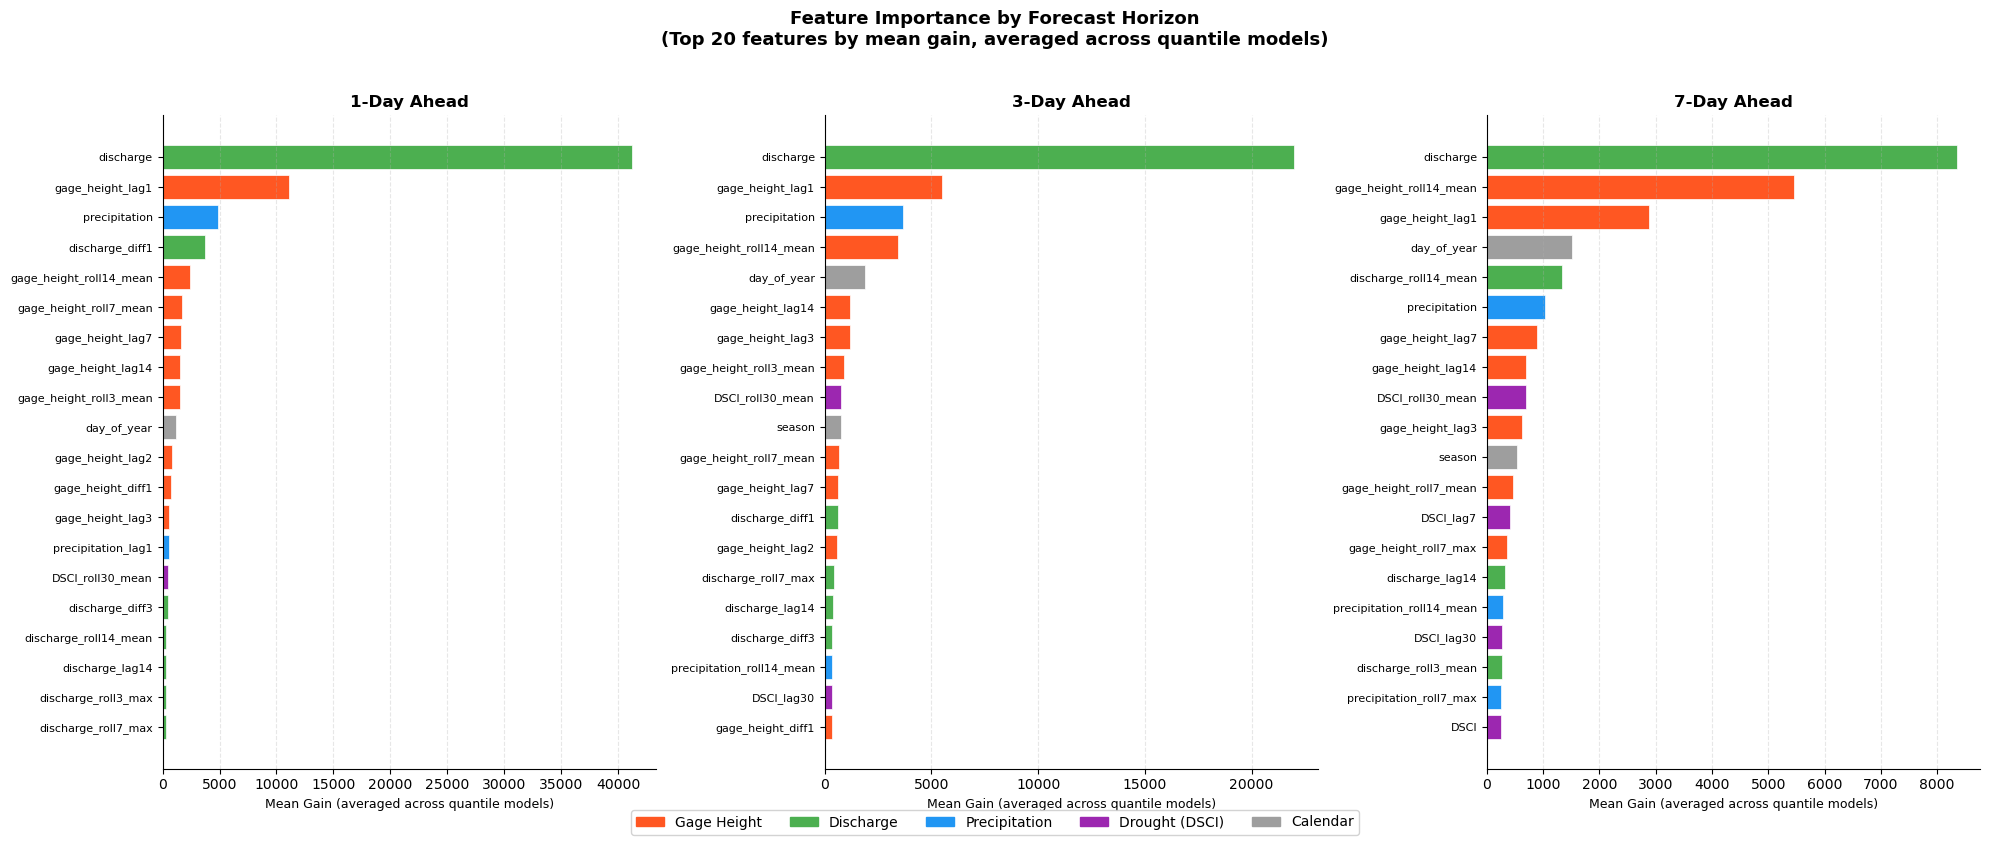

In [25]:
# Number of top features to display per horizon
TOP_N = 20   

HORIZON_LABELS = {1: '1-Day Ahead', 3: '3-Day Ahead', 7: '7-Day Ahead'}

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, horizon in zip(axes, HORIZONS):
    # Average feature importance across the three quantile models sing 'gain'
    importances = np.mean([
        final_models[horizon][q].booster_.feature_importance(importance_type='gain')
        for q in QUANTILES
    ], axis=0)

    # Build a sorted dataframe
    importance_df = pd.DataFrame({
        'feature':    feature_cols,
        'importance': importances,
    }).sort_values('importance', ascending=True).tail(TOP_N)

    # Color bars by feature group
    def get_color(feature):
        if 'precipitation' in feature:
            return '#2196F3'   # Blue
        elif 'discharge' in feature:
            return '#4CAF50'   # Green
        elif 'gage_height' in feature:
            return '#FF5722'   # Orange
        elif 'DSCI' in feature or 'drought' in feature:
            return '#9C27B0'   # Purple
        else:
            return '#9E9E9E'   # Gray for calendar features

    colors = [get_color(f) for f in importance_df['feature']]

    # Horizontal bar chart
    bars = ax.barh(
        importance_df['feature'],
        importance_df['importance'],
        color=colors,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_title(f'{HORIZON_LABELS[horizon]}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Gain (averaged across quantile models)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────

legend_handles = [
    mpatches.Patch(color='#FF5722', label='Gage Height'),
    mpatches.Patch(color='#4CAF50', label='Discharge'),
    mpatches.Patch(color='#2196F3', label='Precipitation'),
    mpatches.Patch(color='#9C27B0', label='Drought (DSCI)'),
    mpatches.Patch(color='#9E9E9E', label='Calendar'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    fontsize=10,
    framealpha=0.85,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'Feature Importance by Forecast Horizon\n(Top 20 features by mean gain, averaged across quantile models)',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Naive persistence comparison

In [13]:
results = []

for horizon in HORIZONS:
    target_col = targets[horizon]

    # Align observed and persistence predictions on the test set
    # y(t) is the gage height at forecast issue time (current day)
    # y(t+h) is the actual future gage height (target)
    y_test       = test_df[target_col].values
    y_persistence = test_df['gage_height'].values

    # LightGBM predictions
    pred_lower  = test_predictions[horizon][0.025]
    pred_median = test_predictions[horizon][0.50]
    pred_upper  = test_predictions[horizon][0.975]

    # Persistence metrics
    p_mae  = mean_absolute_error(y_test, y_persistence)
    p_rmse = root_mean_squared_error(y_test, y_persistence)

    # LightGBM metrics
    m_mae  = mean_absolute_error(y_test, pred_median)
    m_rmse = root_mean_squared_error(y_test, pred_median)
    m_coverage = np.mean(
        (y_test >= pred_lower) & (y_test <= pred_upper)
    )
    m_width = np.mean(pred_upper - pred_lower)

    # Skill score: % improvement over persistence
    # Positive means LightGBM better than persistence
    mae_skill  = (p_mae  - m_mae)  / p_mae  * 100
    rmse_skill = (p_rmse - m_rmse) / p_rmse * 100

    results.append({
        'Horizon':              f'{horizon}-Day',
        'Persistence MAE':      p_mae,
        'LightGBM MAE':         m_mae,
        'MAE Skill (%)':        mae_skill,
        'Persistence RMSE':     p_rmse,
        'LightGBM RMSE':        m_rmse,
        'RMSE Skill (%)':       rmse_skill,
        'LightGBM Coverage':    m_coverage,
        'LightGBM Int. Width':  m_width,
    })

    print(f"\nHorizon {horizon}d")
    print(f"  {'Metric':<22} {'Persistence':>12} {'LightGBM':>12} {'Skill':>10}")
    print(f"  {'-'*58}")
    print(f"  {'MAE (ft)':<22} {p_mae:>12.3f} {m_mae:>12.3f} {mae_skill:>+9.1f}%")
    print(f"  {'RMSE (ft)':<22} {p_rmse:>12.3f} {m_rmse:>12.3f} {rmse_skill:>+9.1f}%")
    print(f"  {'Coverage':<22} {'N/A':>12} {m_coverage:>12.1%}")
    print(f"  {'Interval Width (ft)':<22} {'N/A':>12} {m_width:>12.3f}")

# ── Summary table ─────────────────────────────────────────────────────────────

results_df = pd.DataFrame(results).set_index('Horizon')
results_df.round(3)


Horizon 1d
  Metric                  Persistence     LightGBM      Skill
  ----------------------------------------------------------
  MAE (ft)                      0.426        0.277     +35.0%
  RMSE (ft)                     1.477        1.089     +26.3%
  Coverage                        N/A        83.8%
  Interval Width (ft)             N/A        0.962

Horizon 3d
  Metric                  Persistence     LightGBM      Skill
  ----------------------------------------------------------
  MAE (ft)                      0.730        0.521     +28.5%
  RMSE (ft)                     2.011        1.773     +11.8%
  Coverage                        N/A        81.9%
  Interval Width (ft)             N/A        3.026

Horizon 7d
  Metric                  Persistence     LightGBM      Skill
  ----------------------------------------------------------
  MAE (ft)                      0.986        0.680     +31.0%
  RMSE (ft)                     2.517        1.939     +23.0%
  Coverage         

,Persistence MAE,LightGBM MAE,MAE Skill (%),Persistence RMSE,LightGBM RMSE,RMSE Skill (%),LightGBM Coverage,LightGBM Int. Width
Horizon,,,,,,,,
1-Day,0.426,0.277,34.974,1.477,1.089,26.256,0.838,0.962
3-Day,0.730,0.521,28.517,2.011,1.773,11.831,0.819,3.026
7-Day,0.986,0.680,31.044,2.517,1.939,22.962,0.838,4.031


In [10]:
results_df['MAE Skill (%)']

Horizon
1-Day    34.973524
3-Day    28.517055
7-Day    31.043896
Name: MAE Skill (%), dtype: float64

In [11]:
results_df['RMSE Skill (%)']

Horizon
1-Day    26.255574
3-Day    11.831167
7-Day    22.961522
Name: RMSE Skill (%), dtype: float64